# **APE04: Momentos Estadísticos y Análisis de Tendencia Central con Python**

### **Grupo H**

**Integrantes:** Valeria Agila, José Valencia, Domenica Narváez, Sherman Abarca, Diyer Torres, Gabriel *Suarez*

## **Tarea 1: Validación de Clase Invertida (Semana 4)**
Dado el feriado del 01 de mayo, esta sección evalúa la participación en la clase invertida.

Abra el Jupyter Notebook generado en el trabajo autónomo de la Semana 4.

Asegúrese de que el bloque de código contenga su modificación personal (ej. simulación de la variable de Bernoulli).

Ejecute el script y presente visualmente al docente la PMF (Función de Masa de Probabilidad) generada para validar su puntaje de participación.

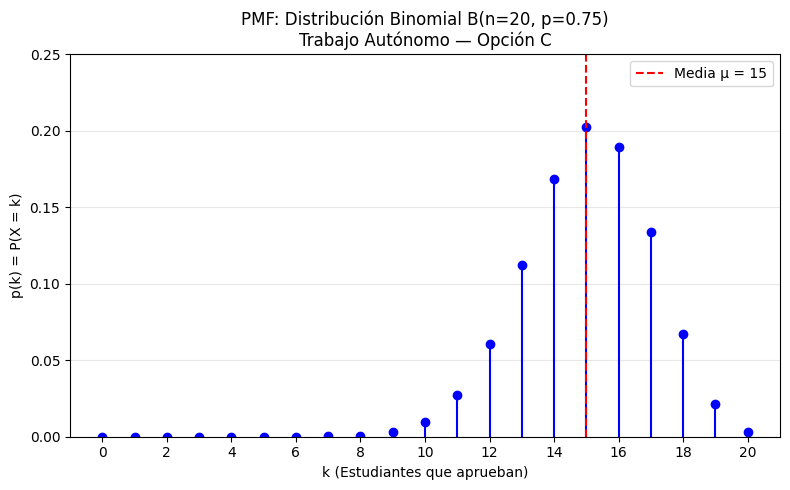

Variable: X ~ Binomial(n=20, p=0.75)
Media μ = n·p = 15.00
Varianza σ² = n·p·(1-p) = 3.75


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Configuración (asegúrate de tener esto al inicio)
plt.rcParams["figure.figsize"] = (12, 5)

# --- Parámetros de la distribución Binomial ---
n = 20      # número de ensayos (estudiantes en el grupo)
p = 0.75    # probabilidad de éxito (aprobar el parcial)

dist_binom = binom(n=n, p=p)
k = np.arange(0, n + 1)
pmf_binom = dist_binom.pmf(k)
cdf_binom = dist_binom.cdf(k)

media    = dist_binom.mean()
varianza = dist_binom.var()

# --- PMF (lo que te pide el docente) ---
plt.figure(figsize=(8, 5))
plt.stem(k, pmf_binom, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.axvline(media, color='red', linestyle='--', linewidth=1.5, label=f'Media μ = {media:.0f}')
plt.xlabel('k (Estudiantes que aprueban)')
plt.ylabel('p(k) = P(X = k)')
plt.title('PMF: Distribución Binomial B(n=20, p=0.75)\nTrabajo Autónomo — Opción C')
plt.xticks(np.arange(0, 21, 2))
plt.ylim(0, 0.25)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Variable: X ~ Binomial(n=20, p=0.75)")
print(f"Media μ = n·p = {media:.2f}")
print(f"Varianza σ² = n·p·(1-p) = {varianza:.2f}")

# **Tarea 2: Cálculo Teórico y Simulación de Esperanza Matemática ( )**

* ***¡IMPORTANTE!*** Tarea hecha en el colab APE_005_Momentos:

**Enlace:** https://colab.research.google.com/drive/1KJe-AWukZJvpMsaOdQuMNo3m_roR0VJU?usp=sharing

# **Tarea 3: Hito del Proyecto - Análisis de Tendencia Central y Dispersión**
Aplique los conceptos teóricos a su conjunto de datos regional.

Cargue su dataset regional utilizando pandas.

Identifique al menos dos variables cuantitativas clave para su estudio.

Desarrolle un script que calcule la media muestral () y la varianza muestral (). Utilice la formulación insesgada donde la suma de cuadrados se divide por .


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 3._remuneraciones_ingresos_adicionales.xlsx to 3._remuneraciones_ingresos_adicionales (1).xlsx


Dataset cargado: 2883 registros, 12 columnas

📊 Variable: Remuneración mensual unificada
   n (tamaño muestral)    : 2883
   Media muestral x̄      : 713.81
   Varianza muestral s²   : 70276.27
   Desviación estándar s  : 265.10

📊 Variable: Total ingresos adicionales
   n (tamaño muestral)    : 2883
   Media muestral x̄      : 128.13
   Varianza muestral s²   : 5685.30
   Desviación estándar s  : 75.40


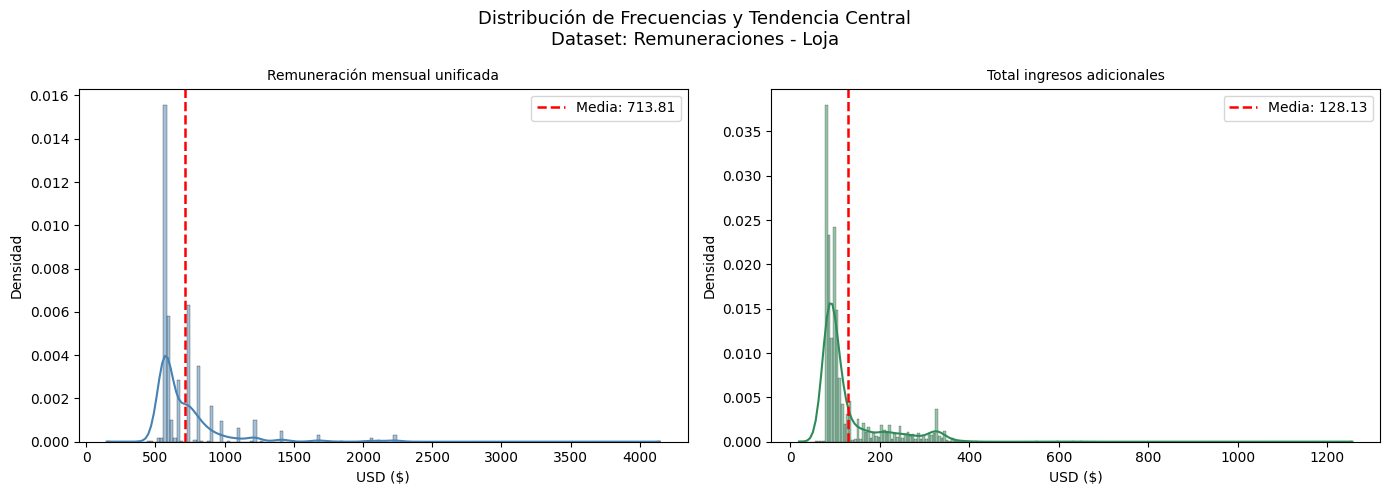

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ── 1. CARGA DEL DATASET ──────────────────────────────────────────────────────
df = pd.read_excel('/content/3._remuneraciones_ingresos_adicionales.xlsx')

print(f"Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas")

# ── 2. VARIABLES CUANTITATIVAS SELECCIONADAS ──────────────────────────────────
var1 = 'Remuneración mensual unificada'
var2 = 'Total ingresos adicionales'

# ── 3. CÁLCULO MANUAL: MEDIA Y VARIANZA MUESTRAL (fórmula insesgada, ddof=1) ──
def estadisticos_muestrales(serie, nombre):
    n = serie.dropna().shape[0]
    media = serie.mean()           # Estimador de E[X]
    varianza = serie.var(ddof=1)   # Σ(xi - x̄)² / (n-1)
    desv_std = serie.std(ddof=1)

    print(f"\n📊 Variable: {nombre}")
    print(f"   n (tamaño muestral)    : {n}")
    print(f"   Media muestral x̄      : {media:.2f}")
    print(f"   Varianza muestral s²   : {varianza:.2f}")
    print(f"   Desviación estándar s  : {desv_std:.2f}")
    return media, varianza

media1, var_s1 = estadisticos_muestrales(df[var1], var1)
media2, var_s2 = estadisticos_muestrales(df[var2], var2)

# ── 4. VISUALIZACIÓN ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Frecuencias y Tendencia Central\nDataset: Remuneraciones - Loja', fontsize=13)

for ax, col, media, color in zip(
    axes,
    [var1, var2],
    [media1, media2],
    ['steelblue', 'seagreen']
):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color=color, stat='density')
    ax.axvline(media, color='red', linestyle='--', linewidth=1.8,
               label=f'Media: {media:.2f}')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('USD ($)')
    ax.set_ylabel('Densidad')
    ax.legend()

plt.tight_layout()
plt.show()